In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("graficos_eda", exist_ok=True)

df_sales = pd.read_csv("FACT_SALES.csv")
df_product = pd.read_excel("DIM_PRODUCT.xlsx")
df_category = pd.read_csv("DIM_CATEGORY.csv")
df_segment = pd.read_excel("DIM_SEGMENT.xlsx")
df_calendar = pd.read_excel("DIM_CALENDAR.xlsx")

In [ ]:
print("FACT_SALES")
print(df_sales.columns.tolist())

print("DIM_PRODUCT")
print(df_product.columns.tolist())

print("DIM_CATEGORY")
print(df_category.columns.tolist())

print("DIM_SEGMENT")
print(df_segment.columns.tolist())

print("DIM_CALENDAR")
print(df_calendar.columns.tolist())

FACT_SALES
['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION']
DIM_PRODUCT
['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY', 'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3']
DIM_CATEGORY
['ID_CATEGORY', 'CATEGORY']
DIM_SEGMENT
['CATEGORY', 'ATTR1', 'ATTR2', 'ATTR3', 'FORMAT', 'SEGMENT']
DIM_CALENDAR
['WEEK', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE']


In [ ]:
df = df_sales.merge(df_calendar, on="WEEK", how="left")
print(df.head())
print(df.columns.tolist())

    WEEK         ITEM_CODE  TOTAL_UNIT_SALES  TOTAL_VALUE_SALES  \
0  34-22  7501058792808BP2             0.006              0.139   
1  34-22     7501058715883             0.487            116.519   
2  34-22     7702626213774             1.391             68.453   
3  34-22     7501058716422             0.022              1.481   
4  34-22     7501058784353             2.037            182.839   

   TOTAL_UNIT_AVG_WEEKLY_SALES              REGION  YEAR  MONTH  WEEK_NUMBER  \
0                        1.000  TOTAL AUTOS AREA 5  2022      8           34   
1                        2.916  TOTAL AUTOS AREA 5  2022      8           34   
2                        5.171  TOTAL AUTOS AREA 5  2022      8           34   
3                        1.833  TOTAL AUTOS AREA 5  2022      8           34   
4                        5.375  TOTAL AUTOS AREA 5  2022      8           34   

        DATE  
0 2022-08-28  
1 2022-08-28  
2 2022-08-28  
3 2022-08-28  
4 2022-08-28  
['WEEK', 'ITEM_CODE', 'TOT

In [ ]:
# unir solo ventas con calendario
df = df_sales.merge(df_calendar, on="WEEK", how="left")

# limpieza básica
df["TOTAL_VALUE_SALES"] = pd.to_numeric(df["TOTAL_VALUE_SALES"], errors="coerce")
df["TOTAL_UNIT_SALES"] = pd.to_numeric(df["TOTAL_UNIT_SALES"], errors="coerce")
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df["REGION"] = df["REGION"].astype(str).str.strip()

df = df.dropna(subset=["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES", "DATE"])

print(df.head())
print(df.columns.tolist())
print(df.shape)

    WEEK         ITEM_CODE  TOTAL_UNIT_SALES  TOTAL_VALUE_SALES  \
0  34-22  7501058792808BP2             0.006              0.139   
1  34-22     7501058715883             0.487            116.519   
2  34-22     7702626213774             1.391             68.453   
3  34-22     7501058716422             0.022              1.481   
4  34-22     7501058784353             2.037            182.839   

   TOTAL_UNIT_AVG_WEEKLY_SALES              REGION  YEAR  MONTH  WEEK_NUMBER  \
0                        1.000  TOTAL AUTOS AREA 5  2022      8           34   
1                        2.916  TOTAL AUTOS AREA 5  2022      8           34   
2                        5.171  TOTAL AUTOS AREA 5  2022      8           34   
3                        1.833  TOTAL AUTOS AREA 5  2022      8           34   
4                        5.375  TOTAL AUTOS AREA 5  2022      8           34   

        DATE  
0 2022-08-28  
1 2022-08-28  
2 2022-08-28  
3 2022-08-28  
4 2022-08-28  
['WEEK', 'ITEM_CODE', 'TOT

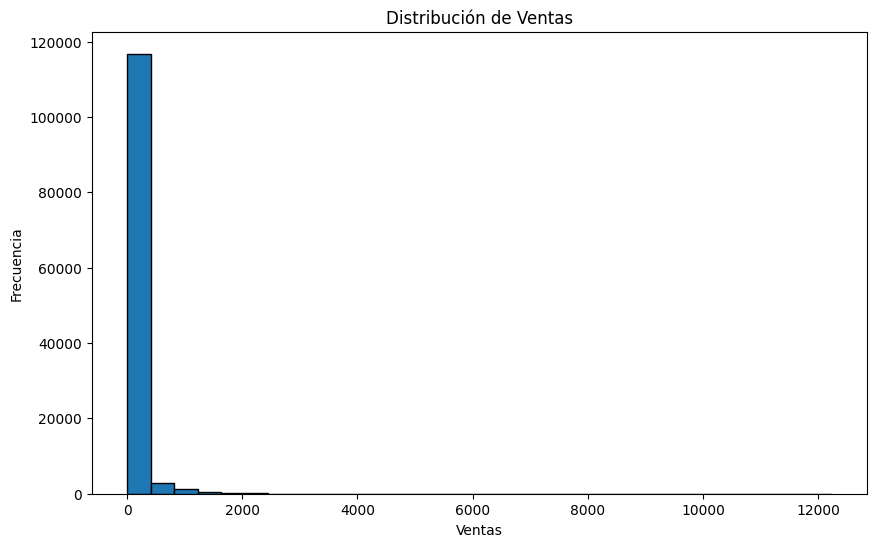

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df["TOTAL_VALUE_SALES"], bins=30, edgecolor="black")
plt.title("Distribución de Ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.savefig("graficos_eda/histograma_ventas.png")
plt.show()

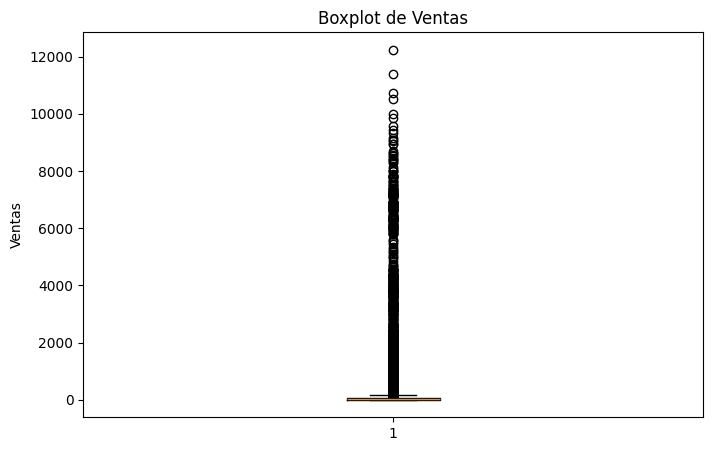

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df["TOTAL_VALUE_SALES"].dropna())
plt.title("Boxplot de Ventas")
plt.ylabel("Ventas")
plt.savefig("graficos_eda/boxplot_ventas.png")
plt.show()

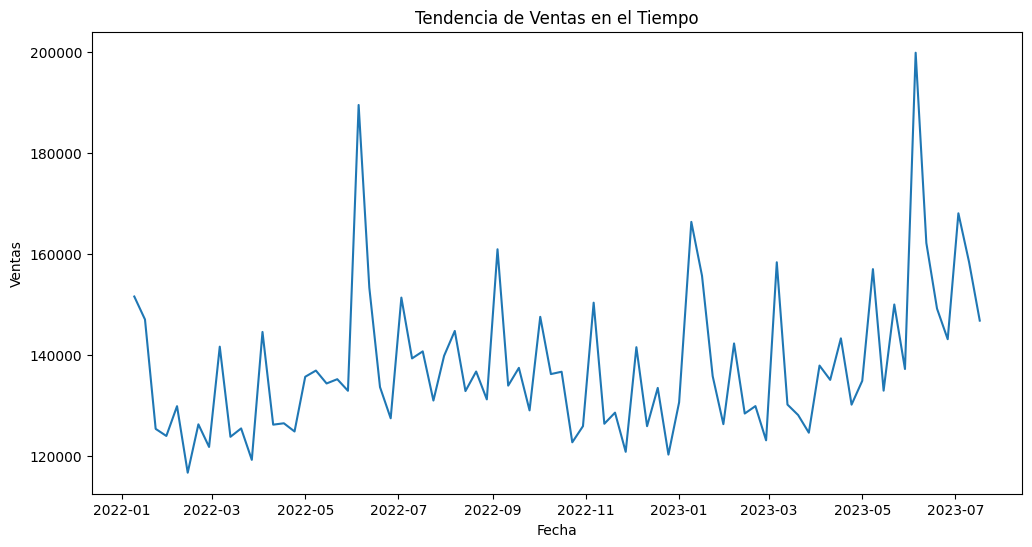

In [ ]:
ventas_tiempo = df.groupby("DATE")["TOTAL_VALUE_SALES"].sum().sort_index()

plt.figure(figsize=(12,6))
plt.plot(ventas_tiempo.index, ventas_tiempo.values)
plt.title("Tendencia de Ventas en el Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.savefig("graficos_eda/tendencia_ventas.png")
plt.show()

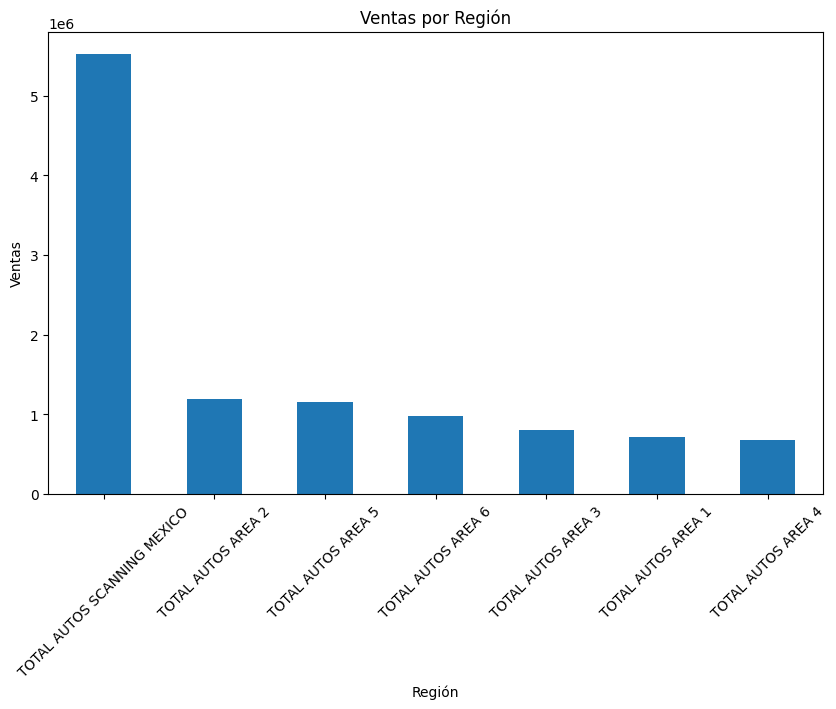

In [ ]:
ventas_region = df.groupby("REGION")["TOTAL_VALUE_SALES"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ventas_region.plot(kind="bar")
plt.title("Ventas por Región")
plt.xlabel("Región")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.savefig("graficos_eda/ventas_region.png")
plt.show()

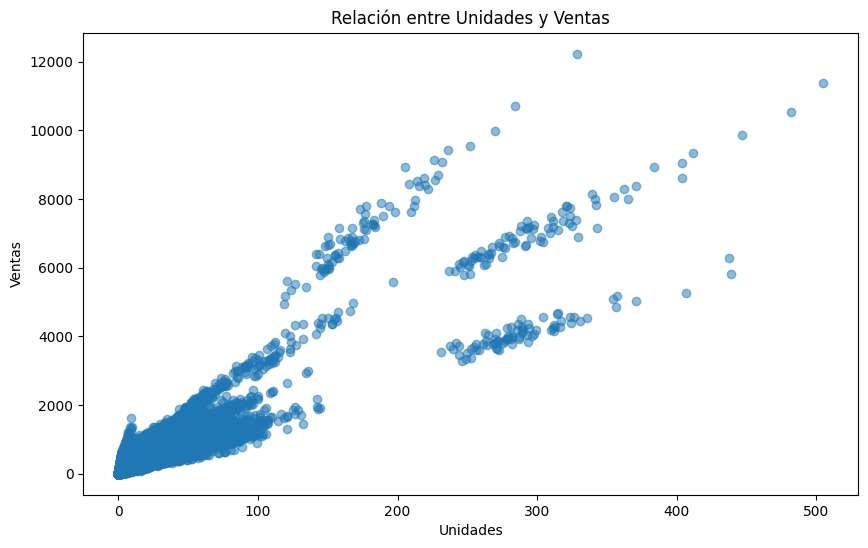

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["TOTAL_UNIT_SALES"], df["TOTAL_VALUE_SALES"], alpha=0.5)
plt.title("Relación entre Unidades y Ventas")
plt.xlabel("Unidades")
plt.ylabel("Ventas")
plt.savefig("graficos_eda/scatter.png")
plt.show()

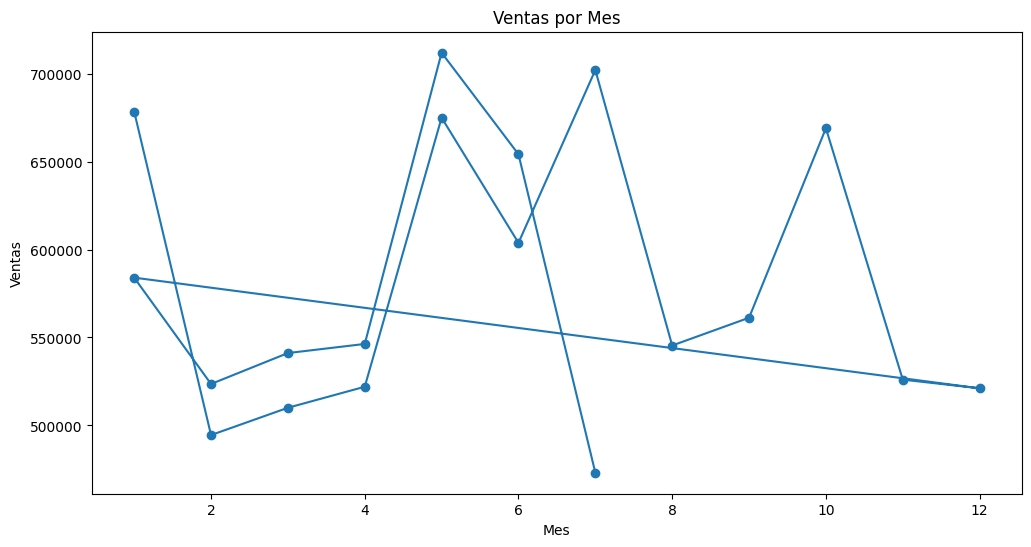

In [ ]:
ventas_mes = df.groupby(["YEAR", "MONTH"])["TOTAL_VALUE_SALES"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(ventas_mes["MONTH"], ventas_mes["TOTAL_VALUE_SALES"], marker="o")
plt.title("Ventas por Mes")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.savefig("graficos_eda/ventas_mes.png")
plt.show()

In [ ]:
ventas_region = df.groupby("REGION")["TOTAL_VALUE_SALES"].sum().sort_values(ascending=False)

porcentaje = (ventas_region / ventas_region.sum()) * 100

print(porcentaje)

REGION
TOTAL AUTOS SCANNING MEXICO    49.999994
TOTAL AUTOS AREA 2             10.765292
TOTAL AUTOS AREA 5             10.444174
TOTAL AUTOS AREA 6              8.910351
TOTAL AUTOS AREA 3              7.277601
TOTAL AUTOS AREA 1              6.467980
TOTAL AUTOS AREA 4              6.134606
Name: TOTAL_VALUE_SALES, dtype: float64


In [ ]:
corr = df[["TOTAL_VALUE_SALES", "TOTAL_UNIT_SALES"]].corr()
print(corr)

                   TOTAL_VALUE_SALES  TOTAL_UNIT_SALES
TOTAL_VALUE_SALES           1.000000          0.916252
TOTAL_UNIT_SALES            0.916252          1.000000


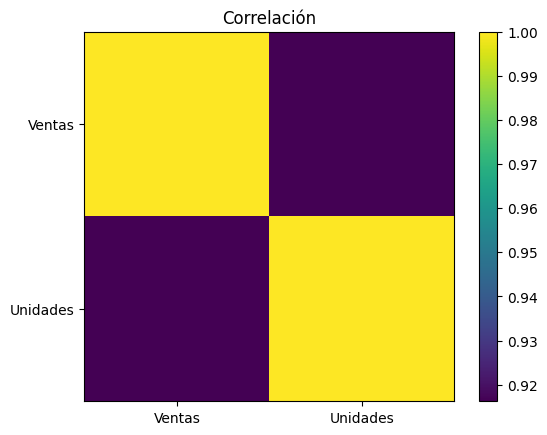

In [ ]:
plt.imshow(corr)
plt.colorbar()
plt.title("Correlación")
plt.xticks([0,1], ["Ventas", "Unidades"])
plt.yticks([0,1], ["Ventas", "Unidades"])
plt.savefig("graficos_eda/correlacion.png")
plt.show()

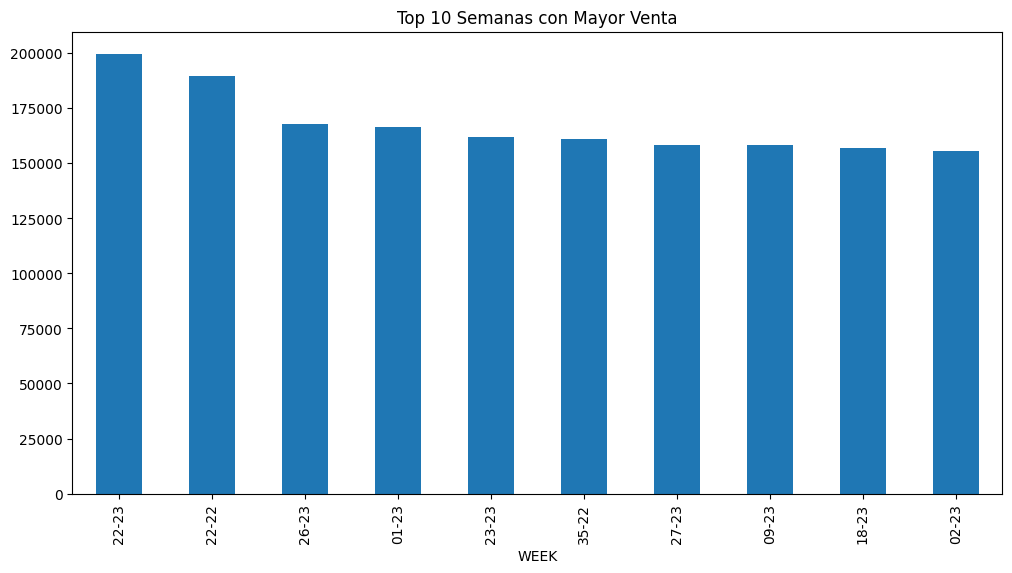

In [ ]:
top_semanas = df.groupby("WEEK")["TOTAL_VALUE_SALES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_semanas.plot(kind="bar")
plt.title("Top 10 Semanas con Mayor Venta")
plt.savefig("graficos_eda/top_semanas.png")
plt.show()

In [ ]:
Q1 = df["TOTAL_VALUE_SALES"].quantile(0.25)
Q3 = df["TOTAL_VALUE_SALES"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["TOTAL_VALUE_SALES"] < Q1 - 1.5*IQR) |
              (df["TOTAL_VALUE_SALES"] > Q3 + 1.5*IQR)]

print("Cantidad de outliers:", len(outliers))

Cantidad de outliers: 14241


/tmp/ipykernel_7247/2066031679.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=regiones)


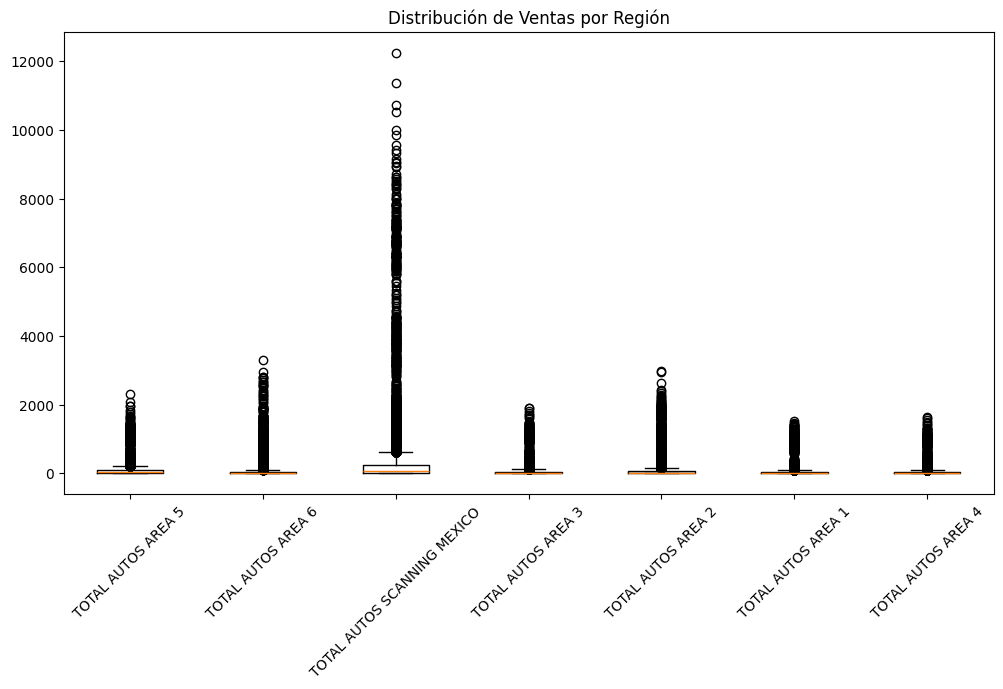

In [ ]:
regiones = df["REGION"].unique()
data = [df[df["REGION"] == r]["TOTAL_VALUE_SALES"] for r in regiones]

plt.figure(figsize=(12,6))
plt.boxplot(data, labels=regiones)
plt.title("Distribución de Ventas por Región")
plt.xticks(rotation=45)
plt.savefig("graficos_eda/boxplot_region.png")
plt.show()